# Импорты библиотек, seed и устройство

In [1]:
# Базовые библиотеки
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
     

torch: 2.7.1+cu118
torchvision: 0.22.1+cu118


In [2]:
import json
import pandas as pd
from pathlib import Path

# Зафиксировал seed и определил устройство 

In [3]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

os.makedirs("artifacts/figures/", exist_ok=True)

device: cuda


# Данные и DataLoader

## Вспомогательные функции

In [4]:

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "", isSave: bool = False, save_title: str = "curves_best") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label = "train_loss")
    plt.plot(epochs, history["val_loss"], label = "val_loss")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.title( (title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    if(isSave is True):
        plt.savefig(f"./artifacts/figures/{save_title}.png")
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label = "train_acc")
    plt.plot(epochs, history["val_acc"], label = "val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title( (title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

## Работа с данными
## Загрузка датасета CIFAR10, определение transform, разбиение на train и test

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
])

train_full = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

100.0%


classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train size: 50000
test size: 10000


## DataLoader и батчи

In [6]:
BATCH_SIZE = 256 if device.type == "cuda" else 64

NUM_WORKERS = 0 if os.name == "nt" else 2

val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([256, 3, 32, 32]) torch.float32
y_batch: torch.Size([256]) torch.int64


# Модель MLP и цикл обучения

## Реализация MLP как nn.Module

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 32 * 32 * 3,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([256, 10])


## Функция обновления весов и счета метрик на val/test

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

## Ранняя остановка

In [9]:

class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


# Эксперименты

In [10]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

# Часть A
## E1
### Базовый MLP для оценки падения loss, роста accuracy и признаков переобучения

epoch 01/20 | train loss=1.6717, acc=0.4087 | val loss=1.5295, acc=0.4589
epoch 02/20 | train loss=1.4492, acc=0.4903 | val loss=1.4515, acc=0.4928
epoch 03/20 | train loss=1.3422, acc=0.5273 | val loss=1.3941, acc=0.5068
epoch 04/20 | train loss=1.2539, acc=0.5588 | val loss=1.3807, acc=0.5166
epoch 05/20 | train loss=1.1793, acc=0.5879 | val loss=1.3828, acc=0.5262
epoch 06/20 | train loss=1.1132, acc=0.6117 | val loss=1.3612, acc=0.5331
epoch 07/20 | train loss=1.0465, acc=0.6333 | val loss=1.3810, acc=0.5334
epoch 08/20 | train loss=0.9880, acc=0.6539 | val loss=1.4114, acc=0.5269
epoch 09/20 | train loss=0.9273, acc=0.6774 | val loss=1.4100, acc=0.5278
epoch 10/20 | train loss=0.8679, acc=0.6954 | val loss=1.4371, acc=0.5366
epoch 11/20 | train loss=0.8109, acc=0.7160 | val loss=1.4743, acc=0.5344
epoch 12/20 | train loss=0.7683, acc=0.7305 | val loss=1.5495, acc=0.5261
epoch 13/20 | train loss=0.7228, acc=0.7459 | val loss=1.5445, acc=0.5248
epoch 14/20 | train loss=0.6660, acc=0

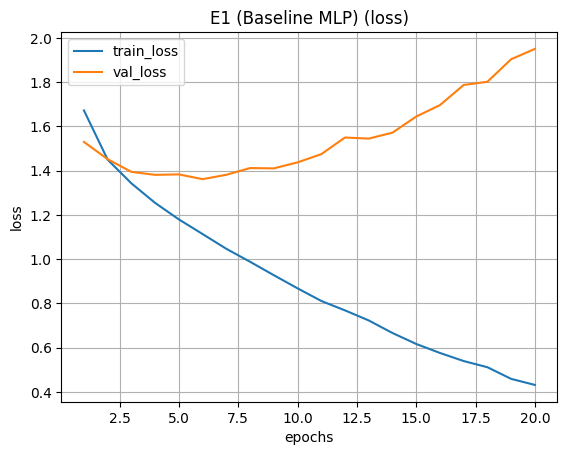

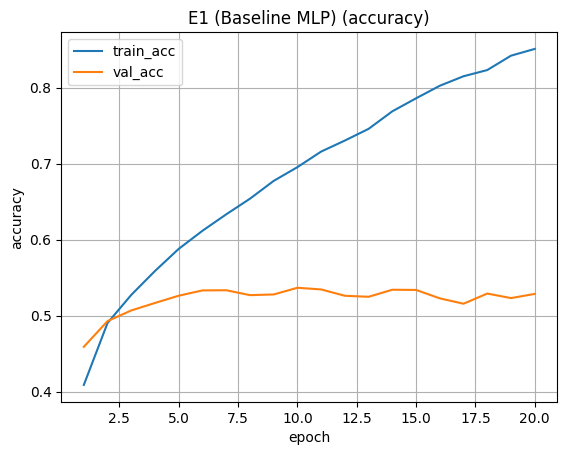

In [11]:
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="E1 (Baseline MLP)")

## E2

epoch 01/20 | train loss=1.7893, acc=0.3639 | val loss=1.5978, acc=0.4411
epoch 02/20 | train loss=1.6130, acc=0.4297 | val loss=1.5195, acc=0.4732
epoch 03/20 | train loss=1.5413, acc=0.4557 | val loss=1.4622, acc=0.4917
epoch 04/20 | train loss=1.4852, acc=0.4769 | val loss=1.4393, acc=0.5040
epoch 05/20 | train loss=1.4447, acc=0.4894 | val loss=1.3978, acc=0.5112
epoch 06/20 | train loss=1.4088, acc=0.5029 | val loss=1.3783, acc=0.5143
epoch 07/20 | train loss=1.3758, acc=0.5140 | val loss=1.3711, acc=0.5170
epoch 08/20 | train loss=1.3561, acc=0.5199 | val loss=1.3574, acc=0.5268
epoch 09/20 | train loss=1.3228, acc=0.5295 | val loss=1.3465, acc=0.5319
epoch 10/20 | train loss=1.3004, acc=0.5390 | val loss=1.3440, acc=0.5303
epoch 11/20 | train loss=1.2872, acc=0.5435 | val loss=1.3410, acc=0.5268
epoch 12/20 | train loss=1.2659, acc=0.5513 | val loss=1.3416, acc=0.5354
epoch 13/20 | train loss=1.2455, acc=0.5588 | val loss=1.3254, acc=0.5394
epoch 14/20 | train loss=1.2291, acc=0

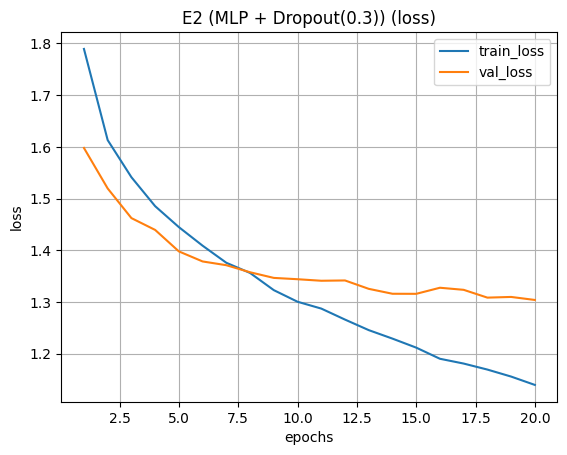

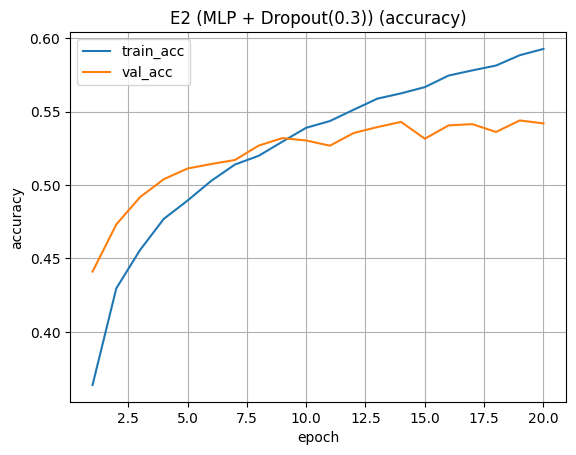

In [12]:
set_seed(42)
dropout_model = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="E2 (MLP + Dropout(0.3))")

## E3

epoch 01/20 | train loss=1.6426, acc=0.4197 | val loss=1.5118, acc=0.4602
epoch 02/20 | train loss=1.4070, acc=0.5010 | val loss=1.4285, acc=0.4921
epoch 03/20 | train loss=1.2969, acc=0.5369 | val loss=1.3448, acc=0.5217
epoch 04/20 | train loss=1.2146, acc=0.5685 | val loss=1.3310, acc=0.5235
epoch 05/20 | train loss=1.1397, acc=0.5967 | val loss=1.3133, acc=0.5315
epoch 06/20 | train loss=1.0789, acc=0.6175 | val loss=1.3031, acc=0.5432
epoch 07/20 | train loss=1.0229, acc=0.6399 | val loss=1.3153, acc=0.5421
epoch 08/20 | train loss=0.9673, acc=0.6587 | val loss=1.3466, acc=0.5395
epoch 09/20 | train loss=0.9149, acc=0.6790 | val loss=1.3531, acc=0.5365
epoch 10/20 | train loss=0.8603, acc=0.6978 | val loss=1.3651, acc=0.5347
epoch 11/20 | train loss=0.8161, acc=0.7144 | val loss=1.3907, acc=0.5350
epoch 12/20 | train loss=0.7676, acc=0.7310 | val loss=1.4475, acc=0.5332
epoch 13/20 | train loss=0.7212, acc=0.7475 | val loss=1.4817, acc=0.5276
epoch 14/20 | train loss=0.6770, acc=0

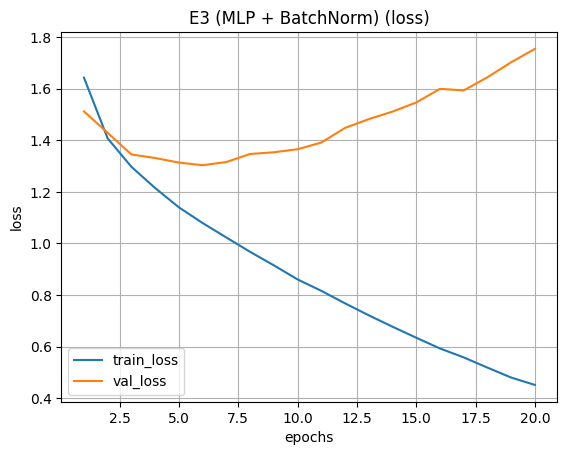

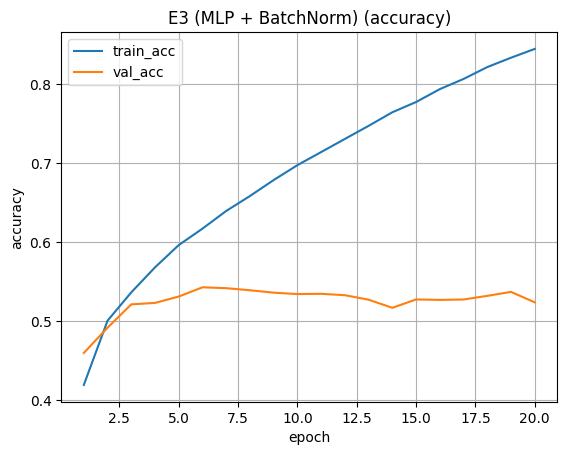

In [13]:
set_seed(42)
bn_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="E3 (MLP + BatchNorm)")

## E4

epoch 01/50 | train loss=1.6426, acc=0.4197 | val loss=1.5118, acc=0.4602
epoch 02/50 | train loss=1.4070, acc=0.5010 | val loss=1.4285, acc=0.4921
epoch 03/50 | train loss=1.2969, acc=0.5369 | val loss=1.3448, acc=0.5217
epoch 04/50 | train loss=1.2146, acc=0.5685 | val loss=1.3310, acc=0.5235
epoch 05/50 | train loss=1.1397, acc=0.5967 | val loss=1.3133, acc=0.5315
epoch 06/50 | train loss=1.0789, acc=0.6175 | val loss=1.3031, acc=0.5432
epoch 07/50 | train loss=1.0229, acc=0.6399 | val loss=1.3153, acc=0.5421
epoch 08/50 | train loss=0.9673, acc=0.6587 | val loss=1.3466, acc=0.5395
epoch 09/50 | train loss=0.9149, acc=0.6790 | val loss=1.3531, acc=0.5365
epoch 10/50 | train loss=0.8603, acc=0.6978 | val loss=1.3651, acc=0.5347
EarlyStopping: остановка на эпохе 10. Лучший val_acc=0.5432


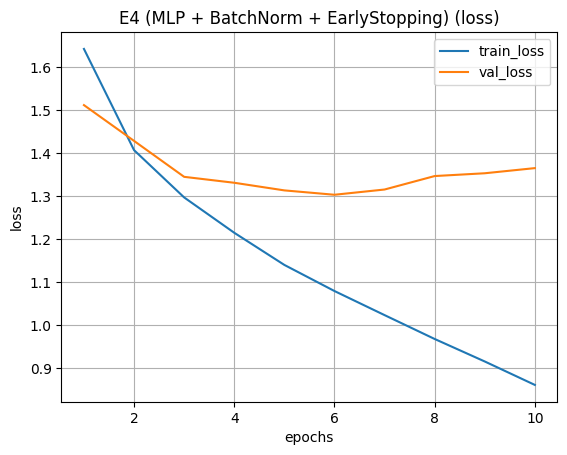

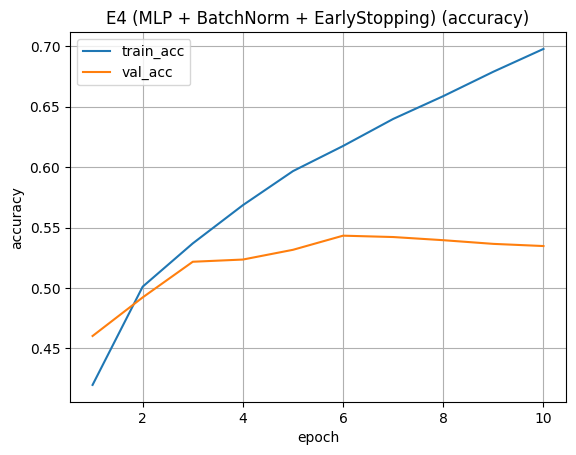

In [14]:
set_seed(42)
combo_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,
    early_stopping=es,
    verbose=True
)

plot_history(history_combo, title="E4 (MLP + BatchNorm + EarlyStopping)", isSave=True)


# Сравнение результатов

In [15]:
results = {
    "baseline": evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)[1],
    "dropout": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "batchnorm": evaluate(bn_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "combo": evaluate(combo_model, test_loader, nn.CrossEntropyLoss(), device)[1],
}

for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")

 baseline: test_acc=0.5275
  dropout: test_acc=0.5377
batchnorm: test_acc=0.5312
    combo: test_acc=0.5384


# Часть B
## O1
### LR слишком большой

epoch 01/8 | train loss=1.8596, acc=0.3374 | val loss=1.6999, acc=0.3783
epoch 02/8 | train loss=1.6233, acc=0.4188 | val loss=1.6225, acc=0.4218
epoch 03/8 | train loss=1.5417, acc=0.4495 | val loss=1.5281, acc=0.4550
epoch 04/8 | train loss=1.4824, acc=0.4719 | val loss=1.5037, acc=0.4617
epoch 05/8 | train loss=1.4388, acc=0.4852 | val loss=1.4816, acc=0.4731
epoch 06/8 | train loss=1.3921, acc=0.5060 | val loss=1.4655, acc=0.4694
epoch 07/8 | train loss=1.3675, acc=0.5113 | val loss=1.4499, acc=0.4868
epoch 08/8 | train loss=1.3308, acc=0.5255 | val loss=1.5010, acc=0.4764


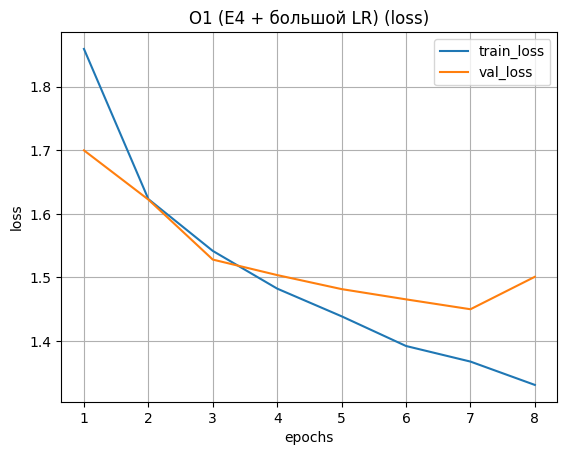

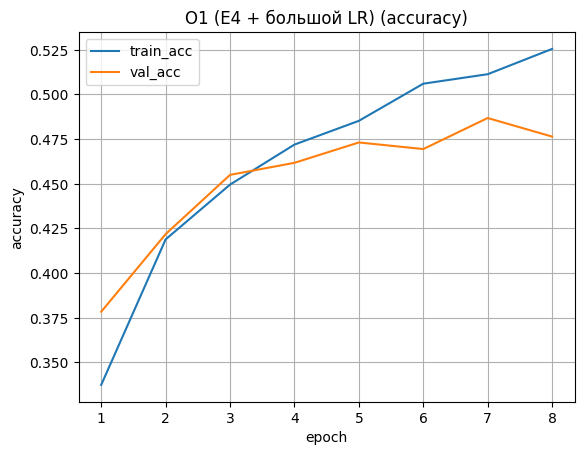

In [16]:
set_seed(42)
o1_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(o1_model.parameters(), lr=1e-1)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o1 = fit(
    o1_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,
    early_stopping=es,
    verbose=True
)

plot_history(history_o1, title="O1 (E4 + большой LR)")

## O2
### LR слишком маленький

epoch 01/8 | train loss=2.0756, acc=0.2715 | val loss=1.9426, acc=0.3414
epoch 02/8 | train loss=1.8754, acc=0.3743 | val loss=1.8393, acc=0.3892
epoch 03/8 | train loss=1.7917, acc=0.4068 | val loss=1.7777, acc=0.4081
epoch 04/8 | train loss=1.7364, acc=0.4262 | val loss=1.7346, acc=0.4207
epoch 05/8 | train loss=1.6926, acc=0.4419 | val loss=1.7031, acc=0.4303
epoch 06/8 | train loss=1.6568, acc=0.4530 | val loss=1.6733, acc=0.4436
epoch 07/8 | train loss=1.6256, acc=0.4657 | val loss=1.6504, acc=0.4534
epoch 08/8 | train loss=1.5975, acc=0.4728 | val loss=1.6278, acc=0.4563


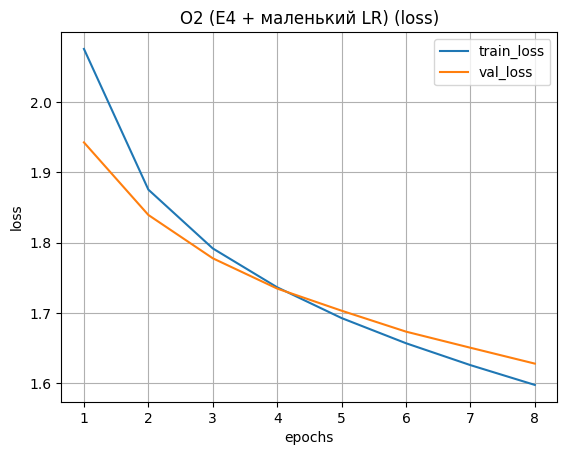

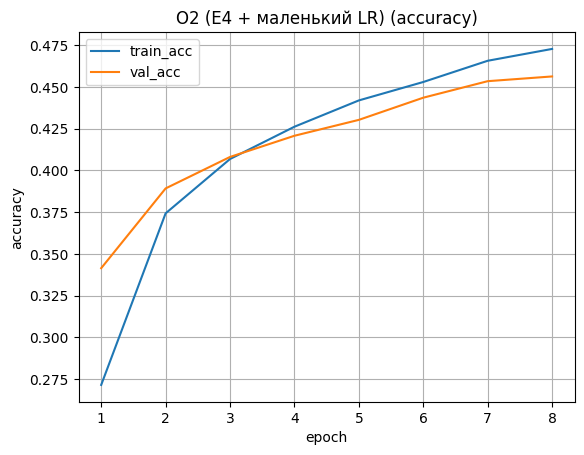

In [17]:
set_seed(42)
o2_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(o2_model.parameters(), lr=1e-5)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o2 = fit(
    o2_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,
    early_stopping=es,
    verbose=True
)

plot_history(history_o2, title="O2 (E4 + маленький LR)")

## O3
### E4 + SGD + momentum + weight_decay

epoch 01/15 | train loss=1.8950, acc=0.3441 | val loss=1.7301, acc=0.4034
epoch 02/15 | train loss=1.6464, acc=0.4395 | val loss=1.6094, acc=0.4480
epoch 03/15 | train loss=1.5369, acc=0.4706 | val loss=1.5351, acc=0.4695
epoch 04/15 | train loss=1.4596, acc=0.4980 | val loss=1.4875, acc=0.4902
epoch 05/15 | train loss=1.3941, acc=0.5196 | val loss=1.4504, acc=0.4958
epoch 06/15 | train loss=1.3407, acc=0.5345 | val loss=1.4231, acc=0.5055
epoch 07/15 | train loss=1.2938, acc=0.5536 | val loss=1.3994, acc=0.5075
epoch 08/15 | train loss=1.2507, acc=0.5691 | val loss=1.3777, acc=0.5105
epoch 09/15 | train loss=1.2057, acc=0.5875 | val loss=1.3830, acc=0.5117
epoch 10/15 | train loss=1.1673, acc=0.5998 | val loss=1.3680, acc=0.5167
epoch 11/15 | train loss=1.1342, acc=0.6114 | val loss=1.3552, acc=0.5204
epoch 12/15 | train loss=1.0997, acc=0.6255 | val loss=1.3529, acc=0.5194
epoch 13/15 | train loss=1.0690, acc=0.6361 | val loss=1.3404, acc=0.5198
epoch 14/15 | train loss=1.0369, acc=0

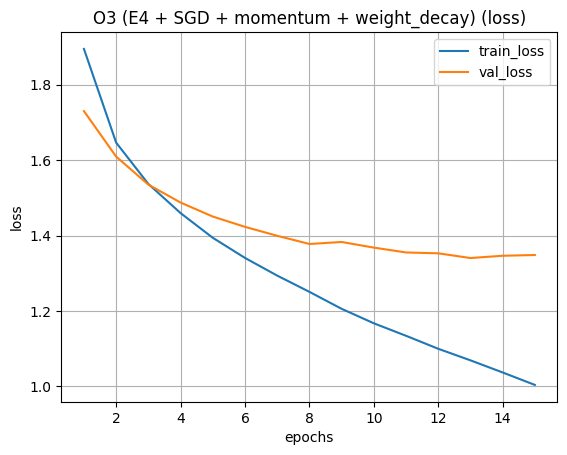

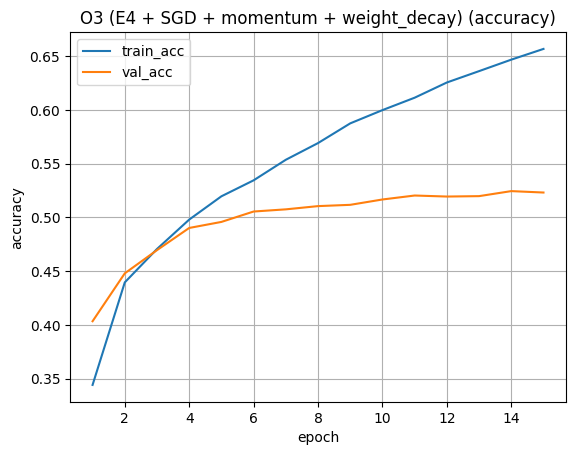

In [18]:
set_seed(42)
o3_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(o3_model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o3 = fit(
    o3_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=15,
    early_stopping=es,
    verbose=True
)

plot_history(history_o3, title="O3 (E4 + SGD + momentum + weight_decay)")

## Таблица результатов по экспериментам

In [19]:
results = [
    {
        'experiment_id': 'E1',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / False',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 20,
        'best_val_accuracy': 0.5303,
        'best_val_loss': 1.3932
    },
    {
        'experiment_id': 'E2',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.3 / False',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 20,
        'best_val_accuracy': 0.5324,
        'best_val_loss': 1.3387
    },
    {
        'experiment_id': 'E3',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 20,
        'best_val_accuracy': 0.5528,
        'best_val_loss': 1.3148
    },
    {
        'experiment_id': 'E4',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 12,
        'best_val_accuracy': 0.5528,
        'best_val_loss': 1.3148
    },
    {
        'experiment_id': 'O1',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'Adam',
        'lr': 1e-1,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 8,
        'best_val_accuracy': 0.4804,
        'best_val_loss': 1.4958
    },
    {
        'experiment_id': 'O2',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'Adam',
        'lr': 1e-5,
        'momentum': 0,
        'weight_decay': 0,
        'epochs_trained': 8,
        'best_val_accuracy': 0.4877,
        'best_val_loss': 1.5031
    },
    {
        'experiment_id': 'O3',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model_summary': '256, 128 / ReLU / 0.0 / True',
        'optimizer': 'SGD',
        'lr': 1e-3,
        'momentum': 0.9,
        'weight_decay': 1e-4,
        'epochs_trained': 11,
        'best_val_accuracy': 0.5354,
        'best_val_loss': 1.3323
    },
]

df_runs = pd.DataFrame(results)

output_path = './artifacts/runs.csv'

df_runs.to_csv(output_path, index=False, encoding='utf-8')

## Конфиг с наилучшими результатами 

In [20]:
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


ARTIFACTS_DIR = Path("artifacts")

best_config = {
    "experiment_id": "E4",
    "dataset": "CIFAR10",
    "seed": 42,
    "architecture": {
        "hidden_sizes": [256, 128],
        "activation": "ReLU",
        "dropout": 0.0,
        "batchnorm": True
    },
    "hyperparameters": {
        "optimizer": "Adam",
        "lr": 0.001,
        "batch_size": 64,
        "epochs": 12,
        "momentum": 0,
        "weight_decay": 0
    },
    "metrics": {
        "best_val_accuracy": 0.5528,
        "best_val_loss": 1.3148
    }
}

save_json(best_config, ARTIFACTS_DIR / "best_config.json")

## Сохранение графиков O1 и O2

In [21]:
def plot_save_history_double(history: dict, history2: dict, title: str = "", title2: str = "", save_title: str = "test_plot2") -> None:
    fig, (plt1, plt2) = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs1 = np.arange(1, len(history["train_loss"]) + 1)
    plt1.plot(epochs1, history["train_loss"], label="train_loss")
    plt1.plot(epochs1, history["val_loss"], label="val_loss")
    plt1.set_xlabel("epoch")
    plt1.set_ylabel("loss")
    plt1.set_title((title + " (loss)") if title else "loss")
    plt1.legend()
    plt1.grid(True)

    epochs2 = np.arange(1, len(history2["train_loss"]) + 1)
    plt2.plot(epochs2, history2["train_loss"], label="train_loss")
    plt2.plot(epochs2, history2["val_loss"], label="val_loss")
    plt2.set_xlabel("epoch")
    plt2.set_ylabel("loss")
    plt2.set_title((title2 + " (loss)") if title2 else "loss")
    plt2.legend()
    plt2.grid(True)

    plt.savefig(f"./artifacts/figures/{save_title}.png")

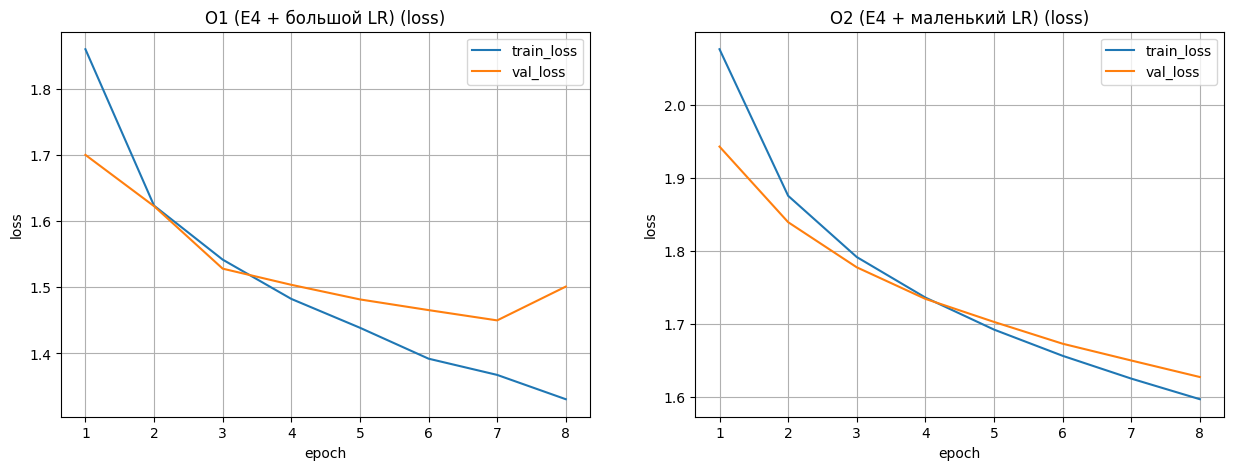

In [22]:
plot_save_history_double(history_o1, history_o2, title="O1 (E4 + большой LR)", title2="O2 (E4 + маленький LR)", save_title="curves_lr_extremes")

# Сохранение лучшей модели с наилучшими результатами

In [23]:
tmp_path = './artifacts/best_model.pt'
torch.save(combo_model.state_dict(), tmp_path)